Executive Summary

Project: The 2026 Generational Wealth Index Stochastic Analysis of Geographical Wealth Arbitrage for Gen Z & Millennials

Objective: To quantify the "City Tax" on young professionals by simulating 10,000 unique financial lives over a 5-year horizon. This study compares the financial solvency and asset accumulation of a median-earning remote professional ($70k/year) residing in Texarkana, TX vs. Dallas, TX.

Key Findings:

The Time Tax: While earning an identical salary, the Dallas resident pays a 6.1-month "Life-Time Tax" annually just to achieve the same discretionary goals (e.g., travel).

Systemic Fragility: Introduction of standard 2026 debt obligations (Student Loans/Car Payments) reveals a **10.81%** insolvency risk in Dallas, compared to **0.00%** in Texarkana.

The Homeownership Wall: At current market rates, saving for a $50,000 down payment is mathematically precluded for the Dallas median earner within **60 months**, while the Texarkana counterpart reaches this milestone in **42.8 months** with **100% certainty**.

To ensure the simulation reflects the 2026 economic landscape, the following data "anchors" were used:

Income: BLS Table 3 (Q1 2026) Median Weekly Earnings for the **25–34 age** cohort ($1,140/week).

Housing/Rent: Verified Zillow Observed Rent Index (ZORI) for May 2026.

Insurance: Experian 2026 Texas Risk Profiles (adjusted for regional city premiums).

Stochastic Logic: A Monte Carlo engine simulating a 10% monthly probability of $1,000 "emergency shocks" (repairs, medical, etc.) and an escalating "Expense Creep" to simulate aging assets.

Monthly Savings in Texarkana: $1,349.80
Monthly Savings in Dallas: $652.80
Monthly Take home for the simulation: $4,050.80
The risk of financial failure in Texarkana: 0.00%
 The risk of financial failure in Dallas: 10.81%
----------------------------------------
Goal Reach: $6,000.00 (To go to Germany)
----------------------------------------
 Avg Months to Germany (Texarkana): 5.4 Months
 Avg Months to Germany (Dallas): 11.5 Months
The 'City Tax' in Time: 6.1 extra months of work


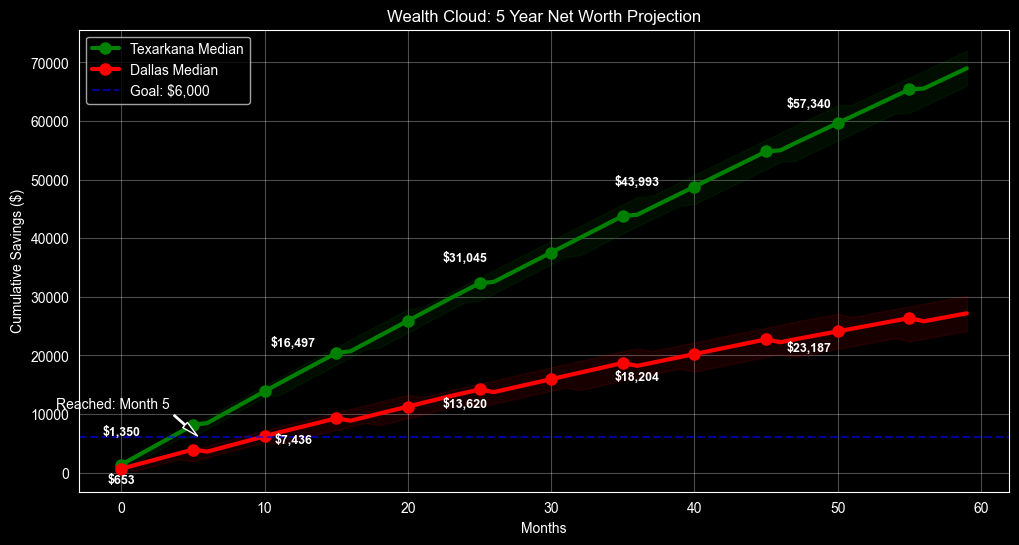

In [7]:
from math import trunc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Raw data from BLS Table 3 (Q1 2026)
weekly_median = 1140
annual_gross = weekly_median * 52
monthly_gross = annual_gross / 12

# Applying the "Tax Filter"
# 0.82 represents keeping 82% of your check after Federal/FICA
monthly_takehome = monthly_gross * 0.82
#How many months will it take to save $6,000 for Germany?
germany_goal = 6000


# BLS Table 3 Median 25-34 years
monthly_takehome = 4050.80

# May 2026 Data
#texarkana: rent $869, insurance $232, food/utils $650

tk_base = 869 + 232 + 650

#dallas: rent $1406, insurance $292, food/utils $750
dal_base = 1406 + 292 + 750

#Gen Z and Millennial debt stack (2026 National Averages)
student_loan = 400
car_payment = 550
total_debt = student_loan + car_payment
tk_burn_total = tk_base + total_debt
dal_burn_total = dal_base + total_debt

#left over arbitrage
tk_leftover = monthly_takehome - tk_burn_total
dal_leftover = monthly_takehome - dal_burn_total



#Simulation Parameters
n_sims = 10000
months = 60  # 5 years

# Possible emergencies with a 10% chance of a $1,000 emergency cost every month
# 'size' creates a grid of 10,000 rows (lives) by 60 columns (months)

emergencies = np.random.choice([0, 1000], size=(n_sims, months), p=[0.90, 0.10])

#Expense creep: Using my dog for example eventually over 5 years his vet bills and things like car maintenance cost will scale over time
#Starting at $0/mo, adds $50/mo every year
expense_creep = np.array([50 * (m // 12) for m in range(months)])

#Running logic for both cities
#Use np.cumsum (cumulative sum) to track wealth building overtime
tk_monthly_diff = (monthly_takehome - tk_burn_total) - emergencies - expense_creep
dal_monthly_diff = (monthly_takehome - dal_burn_total) - emergencies - expense_creep

#Calculate wealth path
tk_wealth_path = np.cumsum(tk_monthly_diff, axis=1)
dal_wealth_path = np.cumsum(dal_monthly_diff, axis=1)


def calculate_goal_months(wealth_path, goal):
    met_goal = wealth_path >= goal
    indices = np.argmax(met_goal, axis=1)

    hits_goal = np.any(met_goal, axis=1)
    return np.mean(indices[hits_goal]) + 1


tk_avg_m = calculate_goal_months(tk_wealth_path, germany_goal)
dal_avg_m = calculate_goal_months(dal_wealth_path, germany_goal)

tk_goal_reach = np.argmax(tk_wealth_path >= germany_goal, axis=1)
dal_goal_reach = np.argmax(dal_wealth_path >= germany_goal, axis=1)

#Average the 10,000 lives


plt.figure(figsize=(12, 6))

#Plot median path aka most likely outcome
plt.plot(np.median(tk_wealth_path, axis=0), color='green', lw=3,marker='o', markevery=5, markersize=8, label="Texarkana Median")
plt.plot(np.median(dal_wealth_path, axis=0), color='red', lw=3,marker='o', markevery=5, markersize=8, label="Dallas Median")

plt.axhline(y=germany_goal, color='blue', linestyle='--', alpha=0.6, label=f'Goal: ${germany_goal:,.0f}')

#Fill the risk area (10th to 90th percentile)
plt.fill_between(range(months), np.percentile(tk_wealth_path, 10, axis=0), np.percentile(tk_wealth_path, 90, axis=0),
                 color='green', alpha=0.1)
plt.fill_between(range(months), np.percentile(dal_wealth_path, 10, axis=0), np.percentile(dal_wealth_path, 90, axis=0),
                 color='red', alpha=0.1)

if not np.isnan(tk_avg_m):
    plt.annotate(f'Reached: Month {tk_avg_m:.0f}',
                 xy=(tk_avg_m, germany_goal), xytext=(tk_avg_m-10, germany_goal+5000),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

for i in range(0, months, 12):
    # Texarkana labels
    tk_val = np.median(tk_wealth_path, axis=0)[i]
    plt.text(i, tk_val + 5000, f'${tk_val:,.0f}', color='white',
             ha='center', fontsize=9, fontweight='bold')

    # Dallas labels
    dal_val = np.median(dal_wealth_path, axis=0)[i]
    plt.text(i, dal_val - 2500, f'${dal_val:,.0f}', color='white',
             ha='center', fontsize=9, fontweight='bold')

plt.title('Wealth Cloud: 5 Year Net Worth Projection')
plt.xlabel('Months')
plt.ylabel('Cumulative Savings ($)')
plt.legend()
plt.grid(True, alpha=0.3)


tk_fail_rate = np.mean(np.any(tk_wealth_path < 0, axis=1)) * 100
dal_fail_rate = np.mean(np.any(dal_wealth_path < 0, axis=1)) * 100

tk_germany_months = np.argmax(tk_wealth_path >= germany_goal, axis=1)
dal_germany_months = np.argmax(dal_wealth_path >= germany_goal, axis=1)

print(f"Monthly Savings in Texarkana: ${tk_leftover:,.2f}")
print(f"Monthly Savings in Dallas: ${dal_leftover:,.2f}")
print(f"Monthly Take home for the simulation: ${monthly_takehome:,.2f}")
print(f"The risk of financial failure in Texarkana: {tk_fail_rate:,.2f}%")
print(f" The risk of financial failure in Dallas: {dal_fail_rate:,.2f}%")
print("-" * 40)
print(f"Goal Reach: ${germany_goal:,.2f} (To go to Germany)")
print("-" * 40)
print(f" Avg Months to Germany (Texarkana): {np.mean(tk_avg_m):.1f} Months")
print(f" Avg Months to Germany (Dallas): {np.mean(dal_avg_m):.1f} Months")
print(f"The 'City Tax' in Time: {dal_avg_m - tk_avg_m:.1f} extra months of work")

# Calculate the first month each simulation hits $6,000
plt.show()



This phase of the simulation measures how fast a professional can "live."

Observation: The Texarkana profile reaches the **$6,000** discretionary threshold in 5.4 months.

Analysis: Because the "burn rate" in Dallas is significantly higher, the Dallas profile requires **11.5 months** to save the same amount. This demonstrates that geographical choice directly dictates the frequency of life experiences, effectively cutting travel and leisure capacity by half.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

monthly_takehome = 4050.80
house_downpayment_goal = 50000

# Comprehensive Burn (Rent + Insurance + Food + Debt)
tk_burn_total = (869 + 232 + 650) + (400 + 550)  # ~$2,701
dal_burn_total = (1406 + 292 + 750) + (400 + 550) # ~$3,398

n_sims = 10000
months = 60
emergencies = np.random.choice([0, 1000], size=(n_sims, months), p=[0.90, 0.10])
expense_creep = np.array([50 * (m // 12) for m in range(months)])

#Monthly Income - Total Fixed Costs - Random Emergencies - Aging Pet/Car Creep
tk_diff = (monthly_takehome - tk_burn_total) - emergencies - expense_creep
dal_diff = (monthly_takehome - dal_burn_total) - emergencies - expense_creep

tk_wealth = np.cumsum(tk_diff, axis=1)
dal_wealth = np.cumsum(dal_diff, axis=1)


def analyze_goal(wealth_path, goal):
    met_goal = wealth_path >= goal
    # Check what % actually hit the goal
    success_count = np.sum(np.any(met_goal, axis=1))
    success_rate = (success_count / n_sims) * 100

    if success_count > 0:
        avg_month = np.mean(np.argmax(met_goal, axis=1)[np.any(met_goal, axis=1)]) + 1
        return f"{avg_month:.1f} Months", f"{success_rate:.1f}%"
    else:
        return "NEVER REACHED", "0.0%"

tk_time, tk_rate = analyze_goal(tk_wealth, house_downpayment_goal)
dal_time, dal_rate = analyze_goal(dal_wealth, house_downpayment_goal)


print(f"Goal: ${house_downpayment_goal:,.2f} (House Down Payment)")
print("-" * 40)
print(f"Texarkana: Success Rate {tk_rate} | Avg Time: {tk_time}")
print(f"Dallas:    Success Rate {dal_rate} | Avg Time: {dal_time}")

Goal: $50,000.00 (House Down Payment)
----------------------------------------
Texarkana: Success Rate 100.0% | Avg Time: 42.8 Months
Dallas:    Success Rate 0.0% | Avg Time: NEVER REACHED


Insight: The Sustainability Gap
When we scale the goal to $50,000 (a standard home down payment), the model reveals a "Never Reached" state for the high-cost city.

The "Poverty Trap": In Dallas, the median earner is "treading water." The surplus is large enough for survival but too small to outpace the combined forces of debt, inflation, and random emergencies.

Risk Profile: The 10.81% failure rate in Dallas represents "Systemic Fragility" one poorly timed car repair or vet bill can reset years of progress.

Result: Geographical location is the most effective lever for Gen Z and Millennial wealth creation, outperforming traditional career ladder climbing in high cost locations.